# IMPORTS

In [21]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import librosa
import soundfile as sf
from PIL import Image
from pydub import AudioSegment
from pydub.utils import which
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import cv2
from sklearn.model_selection import GroupShuffleSplit
from tqdm import tqdm

# DATASET

## CREMA-D

### Load CREMA-D

In [22]:
dataset_folder = "dataset\\CREMA-D\\AudioWAV\\"

data = []

emotion_map = {
    "ANG": "Anger",
    "DIS": "Disgust",
    "FEA": "Fear",
    "HAP": "Happy",
    "NEU": "Neutral",
    "SAD": "Sad",
}


for file in os.listdir(dataset_folder):
    filename, _ = os.path.splitext(file)

    parts = filename.split("_")

    # Speaker
    speaker = parts[0]

    # Path
    path = os.path.join(dataset_folder, file)

    # Emotion
    emotion_code = parts[2]
    emotion = emotion_map.get(emotion_code, "Unknown")

    data.append([speaker, path, emotion])

dataset = pd.DataFrame(data, columns=["speaker", "path", "emotion"])
print(dataset.count())

speaker    7442
path       7442
emotion    7442
dtype: int64


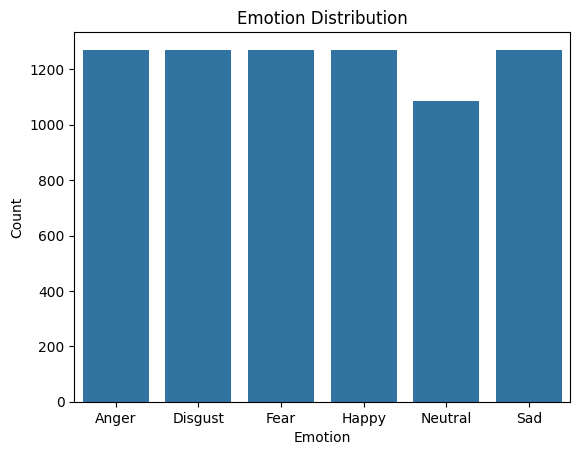

In [23]:
sns.countplot(x="emotion", data=dataset)
plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

In [24]:
def create_csv(df: pd.DataFrame, output_csv: str):
    df.to_csv(output_csv, index=False)

os.makedirs("CSVs", exist_ok=True)
    
create_csv(dataset, "CSVs\\dataset.csv")

### Remove silence

In [ ]:
AudioSegment.converter = which("ffmpeg")

location = "dataset_silenced\\"
os.makedirs(location, exist_ok=True)


def detect_leading_silence(dls_audio):
    dls_chunk_size = 10
    dls_silence_threshold = -50.0

    trim_ms = 0
    dls_audio_length = len(dls_audio)

    while trim_ms < dls_audio_length:
        chunk_dBFS = dls_audio[trim_ms : trim_ms + dls_chunk_size].dBFS
        if chunk_dBFS > dls_silence_threshold:
            break
        trim_ms += dls_chunk_size

    return trim_ms


name = 0
errors = 0
file_data = []

# Process each audio file, remove leading and trailing silence, and save the new audio files
for _, row in dataset.iterrows():
    file_name = f"{location}{name}.wav"

    try:
        audio = AudioSegment.from_file(row["path"], format="wav")
    except:  # noqa: E722
        audio = AudioSegment.from_file(row["path"])

    start_trim = detect_leading_silence(audio)
    end_trim = detect_leading_silence(audio.reverse())

    duration = len(audio)
    new_audio = audio[start_trim : duration - end_trim]

    if len(new_audio) > 0:
        os.makedirs(os.path.dirname(file_name), exist_ok=True)
        new_audio.export(file_name, format="wav")
    else:
        audio.export(file_name, format="wav")
        errors += 1
        print(f"Audio too short: {row['path']}, saved original audio.")

    file_data.append([row["speaker"], file_name, row["emotion"]])
    name += 1

dataset_silenced = pd.DataFrame(file_data, columns=["speaker", "path", "emotion"])
create_csv(dataset_silenced, "CSVs\\dataset_silenced.csv")

### Split dataset

In [ ]:
gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
train_idx, temp_idx = next(gss.split(dataset_silenced, groups=dataset_silenced["speaker"]))

gss = GroupShuffleSplit(test_size=0.5, n_splits=1, random_state=42)
val_idx, test_idx = next(
    gss.split(
        dataset_silenced.loc[temp_idx], groups=dataset_silenced.loc[temp_idx]["speaker"]
    )
)

train_df = dataset_silenced.iloc[train_idx].reset_index(drop=True)
val_df = dataset_silenced.iloc[temp_idx].iloc[val_idx].reset_index(drop=True)
test_df = dataset_silenced.iloc[temp_idx].iloc[test_idx].reset_index(drop=True)

print(f"Train set: {len(train_df)} samples")
print(f"Validation set: {len(val_df)} samples")
print(f"Test set: {len(test_df)} samples")

create_csv(train_df, "CSVs\\train.csv")
create_csv(val_df, "CSVs\\val.csv")
create_csv(test_df, "CSVs\\test.csv")

### Data augmentation

In [ ]:
import random

location = "dataset_augmented\\"
os.makedirs(location, exist_ok=True)


def noise(n_data):
    noise_amp = 0.005 * np.random.uniform() * np.max(np.abs(n_data))
    return n_data + noise_amp * np.random.normal(size=n_data.shape[0])


def stretch(s_data):
    s_rate = np.random.uniform(0.95, 1.05)
    return librosa.effects.time_stretch(s_data, rate=s_rate)


def pitch(p_data, p_sampling_rate):
    p_pitch_factor = np.random.uniform(-1, 1)
    return librosa.effects.pitch_shift(
        p_data, sr=p_sampling_rate, n_steps=p_pitch_factor
    )


name = 0
file_data = []

# Process each audio file, apply random augmentation, and save the new audio files
for _, row in train_df.iterrows():
    data, sampling_rate = librosa.load(row["path"], sr=None)

    # Original audio
    file_name = f"{location}{name}.wav"
    sf.write(file_name, data, sampling_rate)

    file_data.append([row["speaker"], file_name, row["emotion"]])
    name += 1

    # Randomly select an augmentation type
    aug_type = random.choices(
        ["noise", "stretch", "pitch"], weights=[0.4, 0.3, 0.3], k=1
    )[0]

    augment_map = {
        "noise": lambda: noise(data),
        "stretch": lambda: stretch(data),
        "pitch": lambda: pitch(data, sampling_rate),
    }

    aug_data = augment_map[aug_type]()

    file_name = f"{location}{name}.wav"
    sf.write(file_name, aug_data, sampling_rate)

    file_data.append([row["speaker"], file_name, row["emotion"]])
    name += 1

    print(f"Processed {name} files", end="\r", flush=True)


train_df_augmented = pd.DataFrame(file_data, columns=["speaker", "path", "emotion"])
create_csv(train_df_augmented, "CSVs\\dataset_augmented.csv")

# CONVERT TO MEL SPECTROGRAM

In [25]:
from scipy.io import wavfile

location = "features/images/"
os.makedirs(location, exist_ok=True)


def graph_spectrogram(gs_audio, gs_file_name):
    rate, data = wavfile.read(gs_audio)
    fig, ax = plt.subplots(1)
    fig.set_size_inches(0.64, 0.64)
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
    ax.axis("off")
    try:
        pxx, freqs, bins, im = ax.specgram(
            x=data, Fs=rate, cmap="gray_r", noverlap=384, NFFT=512
        )
    except:
        pxx, freqs, bins, im = ax.specgram(
            x=(data[:, 0] + data[:, 1]) / 2,
            Fs=rate,
            cmap="gray_r",
            noverlap=384,
            NFFT=512,
        )
    fig.savefig(gs_file_name, dpi="figure")
    plt.close(fig=fig)


def prepare_images(pi_df, pi_Name):
    data = []
    labels = []

    for idx, row in pi_df.iterrows():
        file_name = f'{location}{pi_Name}_{idx}.png'
        graph_spectrogram(row["path"], file_name)

        image = cv2.imread(file_name, cv2.IMREAD_GRAYSCALE)

        if image is None:
            print(f"Error loading image: {row['path']}")
            continue

        print(f"Processing images: {idx}", end="\r")

        data.append(image)
        labels.append(row["emotion"])

    data = np.array(data, dtype="float") / 255.0
    labels = np.array(labels)

    np.save(f"features/{pi_Name}_images_data.npy", data)
    np.save(f"features/{pi_Name}_images_labels.npy", labels)


data_path_Train = pd.read_csv("CSVs/train.csv")
data_path_Val = pd.read_csv("CSVs/val.csv")
data_path_Test = pd.read_csv("CSVs/test.csv")

prepare_images(data_path_Train, "train")
prepare_images(data_path_Val, "val")
prepare_images(data_path_Test, "test")

d:\Coding\Projects\private_PRJ\speech-emotion-recognition-ravdess\.venv\Lib\site-packages\matplotlib\axes\_axes.py:8283: RuntimeWarning: divide by zero encountered in log10
  Z = 10. * np.log10(spec)


In [5]:
location = "features\\"
csv_dir = "CSVs\\"
train_df = pd.read_csv(os.path.join(csv_dir, "train.csv"))
val_df = pd.read_csv(os.path.join(csv_dir, "val.csv"))
test_df = pd.read_csv(os.path.join(csv_dir, "test.csv"))

MIN_SAMPLES = 2048
TARGET_DURATION = 3.0  # seconds
IMG_SIZE = 224

# Mel params 
# Đây là số lượng dải Mel sẽ được sử dụng để tạo ra spectrogram. 
# Số lượng này ảnh hưởng đến độ phân giải của spectrogram và 
# khả năng mô hình học được các đặc trưng quan trọng từ dữ liệu âm thanh.
N_MELS = 128

# Đây là kích thước của cửa sổ FFT được sử dụng để tính toán spectrogram.
# Kích thước này ảnh hưởng đến độ phân giải tần số của spectrogram và
# khả năng mô hình học được các đặc trưng tần số quan trọng từ dữ liệu âm thanh.
N_FFT = 1024  

# Đây là khoảng cách giữa các cửa sổ FFT liên tiếp khi tính toán spectrogram.
# Khoảng cách này ảnh hưởng đến độ phân giải thời gian của spectrogram và
# khả năng mô hình học được các đặc trưng thời gian quan trọng từ dữ liệu âm thanh.
HOP_LENGTH = 256  

## PyTorch Implementation

In [7]:
# Create a mapping from emotion labels to integers
emotion_list = sorted(train_df["emotion"].unique())
emotion_to_int = {emotion: i for i, emotion in enumerate(emotion_list)}

train_df["label"] = train_df["emotion"].map(emotion_to_int)
val_df["label"] = val_df["emotion"].map(emotion_to_int)


# Custom Dataset
class EmotionDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]["img_path"]
        image = Image.open(img_path).convert("RGB")
        label = self.df.iloc[idx]["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

## Data Transforms and Loaders

In [ ]:
def compute_mean_std(dataset):
    loader = DataLoader(dataset, batch_size=32, shuffle=False)
    mean = torch.zeros(3)
    std = torch.zeros(3)

    for inputs, _ in loader:
        for c in range(3):
            mean[c] += inputs[:, c, :, :].mean()
            std[c] += inputs[:, c, :, :].std()

    mean /= len(loader)
    std /= len(loader)
    return mean.tolist(), std.tolist()

# Tính trên train set (chưa normalize)
raw_dataset = EmotionDataset(train_df, transform=transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
]))

mean, std = compute_mean_std(raw_dataset)
print(f"Mean: {mean}, Std: {std}")

In [ ]:
data_transforms = {
    "train": transforms.Compose(
        [
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.Grayscale(num_output_channels=1),  # giữ 1 channel
            transforms.TrivialAugmentWide(),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),  # normalize đơn giản về [-1, 1]
        ]
    ),
    "val": transforms.Compose(
        [
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),  # normalize đơn giản về [-1, 1]
        ]
    ),
    "test": transforms.Compose(
        [
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),  # normalize đơn giản về [-1, 1]
        ]
    ),
}

# Create Datasets and DataLoaders
train_dataset = EmotionDataset(train_df, transform=data_transforms["train"])
val_dataset = EmotionDataset(val_df, transform=data_transforms["val"])
test_dataset = EmotionDataset(test_df, transform=data_transforms["test"])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

dataloaders = {"train": train_loader, "val": val_loader, "test": test_loader}
dataset_sizes = {
    "train": len(train_dataset),
    "val": len(val_dataset),
    "test": len(test_dataset),
}

# MODEL

## Model Setup

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

for layer in [model.layer3, model.layer4]:
    for param in layer.parameters():
        param.requires_grad = True

# Replace the final fully connected layer
num_ftrs = model.fc.in_features
num_classes = len(emotion_list)
model.fc = nn.Sequential(  # type: ignore
    nn.Linear(num_ftrs, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, num_classes),
)

model = model.to(device)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(
    [
        {"params": model.layer3.parameters(), "lr": 0.0001},
        {"params": model.layer4.parameters(), "lr": 0.0001},
        {"params": model.fc.parameters(), "lr": 0.001},
    ],
    weight_decay=1e-4,
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5, 
)

Using device: cuda:0


## Training Loop

In [20]:
def run_epoch(model, dataloader, criterion, optimizer, phase):
    """
        Run one epoch of training or validation.

    Args:
        model (_type_): _model to train or validate_
        dataloader (_type_): _dataloader for the current phase_
        criterion (_type_): _loss function_
        optimizer (_type_): _optimizer for training_
        phase (_type_): "train" or "val" to indicate the current phase_

    Returns:
        _type_: _epoch_loss, epoch_acc_
    """
    if phase == "train":
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    running_corrects = torch.tensor(0, device=device)

    pbar = tqdm(dataloader, desc=f"{phase.upper():5}", leave=False)

    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        loss, preds = run_batch(model, criterion, optimizer, inputs, labels, phase)

        running_loss += loss * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        pbar.set_postfix(loss=f"{loss:.4f}")

    epoch_loss = running_loss / dataset_sizes[phase]
    epoch_acc = running_corrects.double() / dataset_sizes[phase]

    return epoch_loss, epoch_acc


def run_batch(model, criterion, optimizer, inputs, labels, phase):
    """
        Run one batch of training or validation.

    Args:
        model (_type_): _model to train or validate_
        criterion (_type_): _loss function_
        optimizer (_type_): _optimizer for training_
        inputs (_type_): _input data for the batch_
        labels (_type_): _labels for the batch_
        phase (_type_): "train" or "val" to indicate the current phase_

    Returns:
        _type_: _loss.item(), preds_
    """
    optimizer.zero_grad()

    with torch.set_grad_enabled(phase == "train"):
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        if phase == "train":
            loss.backward()
            optimizer.step()

    return loss.item(), preds


def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    """
        Train the model for a specified number of epochs.

    Args:
        model (_type_): _model to train_
        criterion (_type_): _loss function_
        optimizer (_type_): _optimizer for training_
        scheduler (_type_): _learning rate scheduler_
        num_epochs (int, optional): _number of epochs to train for_. Defaults to 10.

    Returns:
        _type_: _trained model_
    """
    best_loss = float("inf")
    epochs_no_improve = 0
    PATIENCE = 10
    stop_training = False
    current_LR = optimizer.param_groups[0]["lr"]

    for epoch in range(num_epochs):
        if stop_training:
            print(f"Early stopping at epoch {epoch + 1}")
            break

        print(f"Epoch {epoch + 1}/{num_epochs}")
        print("-" * 10)

        for phase in ["train", "val"]:
            epoch_loss, epoch_acc = run_epoch(
                model, dataloaders[phase], criterion, optimizer, phase
            )
            print(f"{current_LR:.2e} {phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase == "val":
                scheduler.step(epoch_loss)

                if epoch_loss < best_loss:
                    best_loss = epoch_loss
                    epochs_no_improve = 0
                    torch.save(model.state_dict(), "best_model.pth")
                else:
                    epochs_no_improve += 1
                    if epochs_no_improve >= PATIENCE:
                        stop_training = True
                        break

    model.load_state_dict(torch.load("best_model.pth"))
    return model


# Train the model
print("Starting training...")
model_ft = train_model(model, criterion, optimizer, scheduler, num_epochs=50)
print("Training complete.")

Starting training...
Epoch 1/50
----------


1.00e-04 train Loss: 1.3005 Acc: 0.4956


1.00e-04 val Loss: 1.1826 Acc: 0.5820
Epoch 2/50
----------


1.00e-04 train Loss: 1.1701 Acc: 0.5543


1.00e-04 val Loss: 1.3213 Acc: 0.5505
Epoch 3/50
----------


...

1.00e-04 train Loss: 0.8257 Acc: 0.7005


1.00e-04 val Loss: 1.3744 Acc: 0.6202
Epoch 7/50
----------


1.00e-04 train Loss: 0.7769 Acc: 0.7251


1.00e-04 val Loss: 1.3286 Acc: 0.6175
Epoch 8/50
----------


KeyboardInterrupt: 

## Evaluate on Validation Set

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def evaluate_model(model, dataloader):
    model.eval()  # Set model to evaluate mode
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    return all_labels, all_preds

# Evaluate on the validation set
print("Evaluating on validation set...")
true_labels, predicted_labels = evaluate_model(model_ft, val_loader)

# Classification Report
print("Classification Report (Validation):")
print(classification_report(true_labels, predicted_labels, target_names=emotion_list))

# Confusion Matrix
cm = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=emotion_list, yticklabels=emotion_list)
plt.title("Confusion Matrix (Validation)")
plt.ylabel("Actual Labels")
plt.xlabel("Predicted Labels")
plt.show()

## Evaluate on Test Set

In [ ]:
# Prepare test data
test_df = pd.read_csv(os.path.join(csv_dir, "test_features.csv"))
test_df["img_path"] = test_df["path"].apply(lambda x: f"{location}test_{test_df.index[test_df['path'] == x][0]}.png")
test_df['label'] = test_df['emotion'].map(emotion_to_int)

test_dataset = EmotionDataset(test_df, transform=data_transforms["test"])
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

# Evaluate on the test set
print("\nEvaluating on test set...")
true_labels, predicted_labels = evaluate_model(model_ft, test_loader)

# Classification Report
print("Classification Report (Test):")
print(classification_report(true_labels, predicted_labels, target_names=emotion_list))

# Confusion Matrix
cm = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=emotion_list, yticklabels=emotion_list)
plt.title("Confusion Matrix (Test)")
plt.ylabel("Actual Labels")
plt.xlabel("Predicted Labels")
plt.show()